# Unused Enzyme Sector Parametrization
Calculation of unused enzyme fraction based on data of Utrilla et al. (2016) and Bruggeman et al. (2020)
Main assumptions:
- at mu = 0 h^(-1) the 37% of the metabolic proteins is unused (Bruggeman et al. 2020)
- all non growth proteins in ALE strain are housekeeping proteins
- all non growth proteins in WT strain are either housekeeping or unused proteins
(Although they say that mostly the hedging genes are downresulated, those are not related to growth rate)
See Figure 5C and Table S2
- the unused enzyme sector is related to substrate uptake rate (Alter et al. 2021)


### 0. Setting up the notebook environment

In [12]:
#packages
import os
import pandas as pd
import numpy as np
import plotly.graph_objs as go
import math
import datetime
from PAModelpy.EnzymeSectors import UnusedEnzymeSector

if os.path.split(os.getcwd())[1] ==  'i1_preprocessing':
    os.chdir('../..')

from Scripts.pam_generation import setup_ecoli_pam
from Modules.utils.sector_config_functions import (perform_linear_regression, plot_unused_protein_vs_mu,
                                                            get_model_simulations_vs_sector,
                                                  change_proteinsector_relation_from_growth_to_substrate_uptake)
from Modules.utils.pamparametrizer_setup import save_sector_information_to_excel
#also need xlwt for to_excel function in pandas

In [13]:
#constants
#files and file paths
MODEL_DIR ='Models'
PAM_DATA_FILE_PATH = os.path.join('Data', 'proteinAllocationModel_iML1515_EnzymaticData_py.xls')
VALID_DATA_FILE_PATH = os.path.join('Data', 'Ecoli_phenotypes', 'Ecoli_phenotypes_py.xls')

#data parsing
MEASURED_PROTEIN_FRACTION = 0.55*0.55#0.55 * 0.55 #measured proteome vs g_p/gcdw in Ecoli
GLC_UPTAKE_RXN_ID = 'EX_glc__D_e'
BIOMASS_RXN_ID = 'BIOMASS_Ec_iML1515_core_75p37M'

# MAX_GROWTH_ALE = 0.86 # by Utrilla et al (2016) in minimal medium or 0.98 by LaCroix et al (2015)?
MAX_GROWTH_ALE = math.log(2)*1.63#Or from lenski experiment which is ln(2)*1.63(doublings per hour)
UNUSED_PROTEIN_INTERCEPT = 0.37*MEASURED_PROTEIN_FRACTION #37% (Bruggeman et al (2020)) of all the proteins which can be measured


#output file path
# Create a datetime object for the current date
current_date = datetime.datetime.now()
# Format the date as yymmdd
formatted_date = current_date.strftime('%y%m%d')

OUTPUT_FILE_PATH = os.path.join('Results', 
                                '1_preprocessing', 
                                f'proteinAllocationModel_iML1515_EnzymaticData_{formatted_date}.xlsx')
#only define this one if you are updating the current parameters
# PAM_DATA_FILE_PATH_parameters = os.path.join('Results', 
#                                 '1_preprocessing', 
#                                 f'proteinAllocationModel_iML1515_EnzymaticData_250225.xlsx')


## 1. Setting up the model

In [14]:
pamodel = setup_ecoli_pam(pam_data_file_path = os.path.join(
    'Data', 'proteinAllocationModel_iML1515_EnzymaticData_py.xls'),
                          sensitivity=False)

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector



/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:252: UserWarning: Molar mass for E332 is invalid: 0.0
  warnings.warn(f"Molar mass for {enz.id} is invalid: {molmass}")


Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedProteinSector

Done with setting up the proteome allocation model iML1515



## 2. Run simulations to see how the growth rate relates to unused protein sector

In [15]:
substrate_uptake_rates = np.arange(-11, 1, 1)
ups_sector = pamodel.sectors.UnusedProteinSector

print('Running simulations for the PAM with the old parameters')
simulation_results = get_model_simulations_vs_sector(pamodel, GLC_UPTAKE_RXN_ID, GLC_UPTAKE_RXN_ID, 
                                                     substrate_uptake_rates,
                                                     ups_sector.intercept/1e3, ups_sector.slope/1e3, 
                                                     sector_name = 'unused_protein',
                                                    to_save = BIOMASS_RXN_ID)


Running simulations for the PAM with the old parameters
Running simulations with  -11 mmol/g_cdw/h of substrate going into the system
Running simulations with  -10 mmol/g_cdw/h of substrate going into the system
Running simulations with  -9 mmol/g_cdw/h of substrate going into the system
Running simulations with  -8 mmol/g_cdw/h of substrate going into the system
Running simulations with  -7 mmol/g_cdw/h of substrate going into the system
Running simulations with  -6 mmol/g_cdw/h of substrate going into the system
Running simulations with  -5 mmol/g_cdw/h of substrate going into the system
Running simulations with  -4 mmol/g_cdw/h of substrate going into the system
Running simulations with  -3 mmol/g_cdw/h of substrate going into the system
Running simulations with  -2 mmol/g_cdw/h of substrate going into the system
Running simulations with  -1 mmol/g_cdw/h of substrate going into the system
Running simulations with  0 mmol/g_cdw/h of substrate going into the system


/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


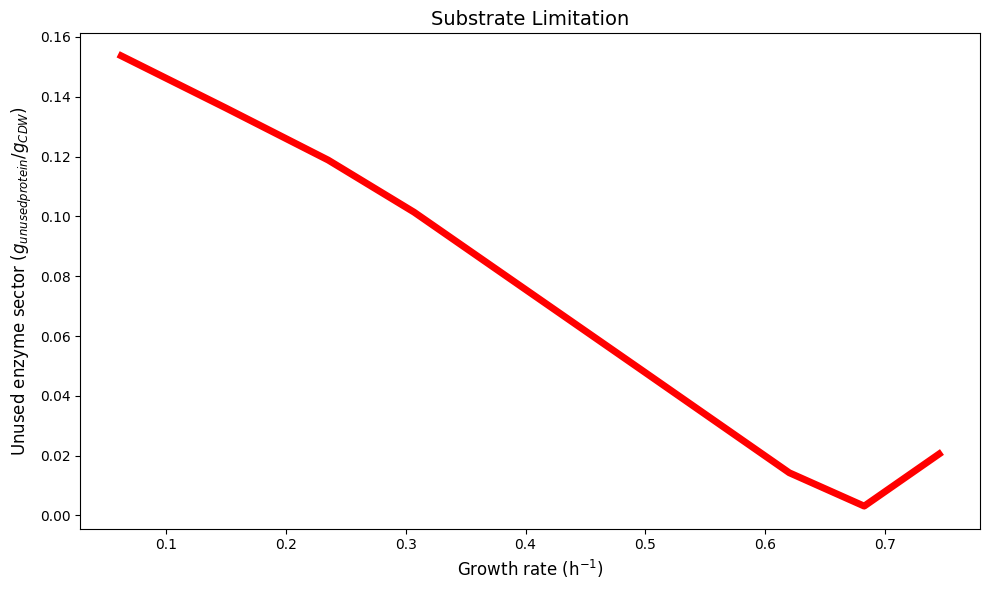

In [16]:
plot_unused_protein_vs_mu(simulation_results,
                          BIOMASS_RXN_ID)

## 3. New relation mu and unused protein

The new slope based on the maximal growth after ALE: 0.09906358432607194


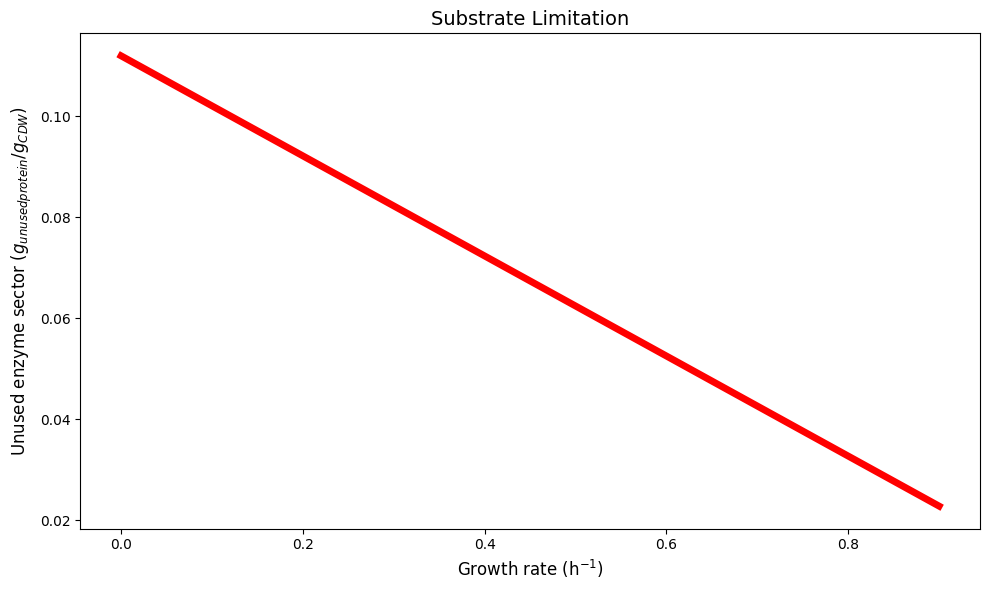

In [17]:
x = [0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]
ue_0 = UNUSED_PROTEIN_INTERCEPT
y = [(ue_0-ue_0/MAX_GROWTH_ALE*mu) for mu in x]
print('The new slope based on the maximal growth after ALE:', ue_0/MAX_GROWTH_ALE)

envisioned_simulation_results = pd.DataFrame({
    BIOMASS_RXN_ID: x, 'unused_protein': y
})

plot_unused_protein_vs_mu(envisioned_simulation_results,
                          BIOMASS_RXN_ID)
# fig = go.Figure()
# fig.add_trace(go.Scatter(x=x, 
#                              y=y,
#                              mode='lines', line = dict(width = 5)))
# fig.update_xaxes(title_text = 'Growth rate ($h^{-1}$)', range=[0,1])
# fig.update_yaxes(title_text = 'Unused enzyme sector ($g_{unusedprotein}/g_{CDW}$)', range = [0,0.2])
    
# fig.update_traces(marker_size=10)
# fig.update_layout(font = dict(size = 12), title = 'Glucose limitation')
# fig.show()

In [18]:
#change the enzyme sector information
pamodel_new = setup_ecoli_pam(pam_data_file_path = os.path.join(
    'Data', 'proteinAllocationModel_iML1515_EnzymaticData_py.xls'),sensitivity=False)
pamodel_new.change_sector_parameters(sector = pamodel.sectors.get_by_id('UnusedProteinSector'),
                                 slope= -ue_0/MAX_GROWTH_ALE, intercept=ue_0, lin_rxn_id= BIOMASS_RXN_ID)

Setting up the proteome allocation model iML1515

Add total condition-dependent protein constraint
	Total protein concentration: 0.258 g/gDW

Add active protein sector



/home/samiralvdb/Documents/3_Projects/7_MCA_analysis/PAModelpy/src/PAModelpy/PAModel.py:252: UserWarning: Molar mass for E332 is invalid: 0.0
  warnings.warn(f"Molar mass for {enz.id} is invalid: {molmass}")


Add the following protein sector: TranslationalProteinSector

Add the following protein sector: UnusedProteinSector

Done with setting up the proteome allocation model iML1515



In [19]:
#run the simulations
simulation_results_new = get_model_simulations_vs_sector(pamodel_new, 
                                                         GLC_UPTAKE_RXN_ID, 
                                                         BIOMASS_RXN_ID, 
                                                         substrate_uptake_rates,
                                                         ue_0, 
                                                         -ue_0/MAX_GROWTH_ALE,
                                                         sector_name = 'unused_protein')

Running simulations with  -11 mmol/g_cdw/h of substrate going into the system
Running simulations with  -10 mmol/g_cdw/h of substrate going into the system
Running simulations with  -9 mmol/g_cdw/h of substrate going into the system
Running simulations with  -8 mmol/g_cdw/h of substrate going into the system
Running simulations with  -7 mmol/g_cdw/h of substrate going into the system
Running simulations with  -6 mmol/g_cdw/h of substrate going into the system
Running simulations with  -5 mmol/g_cdw/h of substrate going into the system
Running simulations with  -4 mmol/g_cdw/h of substrate going into the system
Running simulations with  -3 mmol/g_cdw/h of substrate going into the system
Running simulations with  -2 mmol/g_cdw/h of substrate going into the system
Running simulations with  -1 mmol/g_cdw/h of substrate going into the system
Running simulations with  0 mmol/g_cdw/h of substrate going into the system


/home/samiralvdb/Software/anaconda3/envs/PAModelpy/lib/python3.9/site-packages/cobra/util/solver.py:554: UserWarning: Solver status is 'infeasible'.
  warn(f"Solver status is '{status}'.", UserWarning)


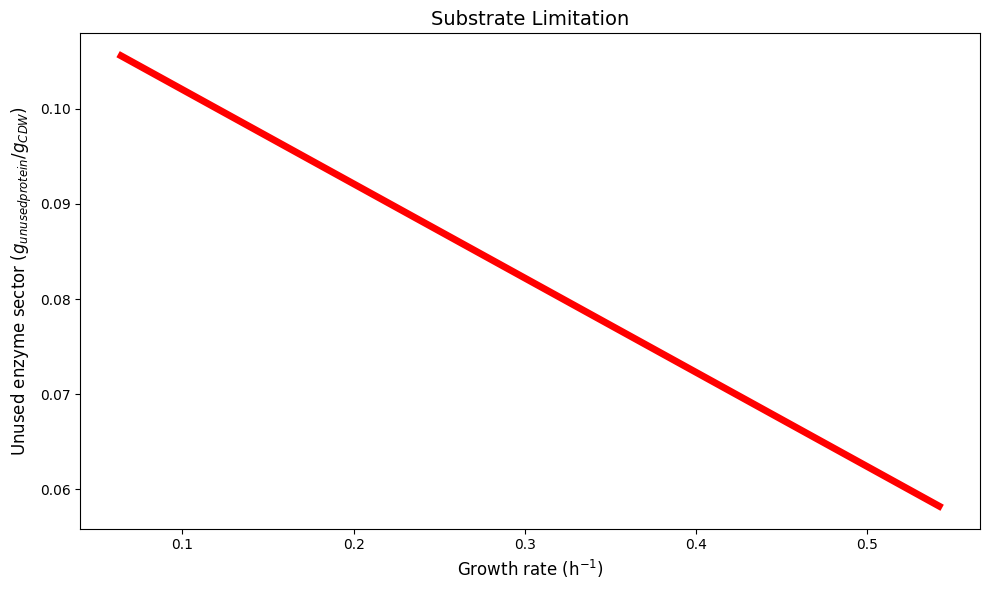

In [20]:
plot_unused_protein_vs_mu(simulation_results_new, BIOMASS_RXN_ID)

## Convert correlation to growth rate to correlation to substrate uptake rate

In [21]:
unused_sector_vs_substrate = change_proteinsector_relation_from_growth_to_substrate_uptake(
    pamodel_new,
    params={
        'slope': -ue_0/MAX_GROWTH_ALE,
        'intercept':ue_0
    },
    sector_id='UnusedProteinSector',
    substrate_uptake_id = 'EX_glc__D_e',
    substrate_range = np.arange(-4,0,1)
)

Running simulations with  -4 mmol/g_cdw/h of substrate going into the system
Running simulations with  -3 mmol/g_cdw/h of substrate going into the system
Running simulations with  -2 mmol/g_cdw/h of substrate going into the system
Running simulations with  -1 mmol/g_cdw/h of substrate going into the system


In [22]:
save_sector_information_to_excel(
        param_vs_lin_rxn=unused_sector_vs_substrate,
        param_vs_growth={
            'slope': -ue_0/MAX_GROWTH_ALE,
            'intercept': ue_0
        },
        biomass_rxn=BIOMASS_RXN_ID,
        lin_rxn_id='EX_glc__D_e',
        sector_id='UnusedEnzyme',
        pam_data_file=OUTPUT_FILE_PATH)

Results/1_preprocessing/proteinAllocationModel_iML1515_EnzymaticData_250912.xlsx
         Parameter         Value                Value_for_growth        Unit  \
0          id_list   EX_glc__D_e  BIOMASS_Ec_iML1515_core_75p37M         NaN   
1           ups_mu      0.008943                       -0.099064   g/g_CDW/h   
2            ups_0      0.114491                        0.111925     g/g_CDW   
3         mol_mass  39477.787843                    39477.787843       g/mol   
4  substrate_range           NaN                [-4, -3, -2, -1]  mmol/gDW/h   

                                         Description  
0  biomass formation reaction ID (representing gr...  
1  slope of relation between growth rate and prot...  
2  Protein concentration allocated to excess enzy...  
3                   Molar mass of a fictional enzyme  
4  Range of values of susbstrate uptake which are...  
